In [106]:
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta
import math
# import matplotlib.pyplot as plt
# import numpy as np
import plotly.express as px
import plotly.graph_objects as go

remember:
- check for duplicates in sub-dfs
- function for creating sub-dfs
- think about placement for the functions - revise order
- merge plotting with creating the sub-df
- collect data from year prior to 08/12/24
- acled login credentials - update and share

In [107]:
dir_processed = Path('../data/processed')
dir_processed.mkdir(exist_ok=True)
dir_raw = Path('../data/raw')
dir_raw.mkdir(exist_ok=True)

In [108]:
def df_index(dataframe):
    rows = len(dataframe)

    dataframe.index = range(1, rows+1)
    
    return dataframe

In [109]:
def color_map(category):
    colors = [
        "#899499", 
        "#D3D3D3", 
        "#708090", 
        "#A9A9A9", 
        "#808080", 
        "#6082B6", 
        "#4F4F4F", 
        "#D3D3D3"
        ] 
    return {event: colors[i] for i, event in enumerate(category)}

In [111]:
"refactored return statement after Lecture W03D04"

def color_map_grey(selected_category, category_list):
    return {event: "#6D8196" if category_list[i] == selected_category else "#D3D3D3" for i in category_list}

In [126]:
def event_names(df, column):
    return list(df[column].unique())

In [112]:
dataset = pd.read_csv(dir_processed / 'dataset.csv')
dataset.index = dataset.index + 1

Part 1: Analyse conflict event types since the regime fall

In [113]:
dataset_grouped = (
    dataset
    .groupby(['interval', 'event_type'], as_index=False)
    .agg(event_count=('event_type', 'size'))
)


In [114]:
dataset_dates = dataset[['interval', 'start date', 'end date']]

In [ ]:
dataset_dates = dataset_dates.drop_duplicates()
df_index(dataset_dates)

In [116]:
# dataset_grouped
data_grouped_with_dates = pd.merge(dataset_grouped, dataset_dates, on='interval')

In [117]:
dataset_grouped.to_csv(dir_processed/'counts_per_event_type.csv', index=False)

In [118]:
# color_map = {
#     'Strategic developments': "#899499" ,
#     "Battles": '#708090',
#     "Explosions/Remote violence": '#A9A9A9',
#     "Protests": "#808080",
#     "Riots": '#6082B6',
#     'Violence against civilians': "#D3D3D3"
# }

# color_map_pop = {
#     'Strategic developments': '#6082B6',
#     "Battles": "#D3D3D3",
#     "Explosions/Remote violence": "#D3D3D3",
#     "Protests": "#D3D3D3",
#     "Riots": "#D3D3D3",
#     'Violence against civilians': "#D3D3D3"
# }

In [119]:
# def event_names(event):

#     names_event_types = dataset[event].unique()
#     print(names_event_types)

#     event_types = []

#     return (event_types.append(et) for et in names_event_types)

# names = event_names('event_type')

In [120]:
def event_names(df, column):
    return list(df[column].unique())

In [121]:
names = event_names(dataset, 'event_type')
names

['Strategic developments',
 'Violence against civilians',
 'Explosions/Remote violence',
 'Protests',
 'Battles',
 'Riots']

In [122]:
"refactored return statement after Lecture W03D04"

def color_map_grey(selected_category, category_list):
    return {event: "#6A89A7" if category_list[i] == selected_category else "#D3D3D3" for i, event in enumerate(category_list)}

In [123]:
plot_events_sdpop = px.bar(
    dataset_grouped, 
    x='interval', 
    y='event_count', 
    color='event_type',
    color_discrete_map=color_map_grey('Strategic developments', names),
    title='Conflict events since the regime overthrow, strategic developments have gradually become more prominent',
    labels={'interval': 'Months elapsed since 08/12/2024', 'event_count': 'Number of events'}
)

plot_events_sdpop.update_layout(
    title_font_size=14, font_size=10, yaxis=dict(nticks=10), 
    legend=dict(title=(dict(text="Events")))
)
plot_events_sdpop.update_xaxes(dtick=1)

In [124]:
plot_events_sdpop.write_html("../docs/assets/bar_events_sd_pop.html")

In [ ]:
names = list(dataset['event_type'].unique())
names

['Strategic developments',
 'Violence against civilians',
 'Explosions/Remote violence',
 'Protests',
 'Battles',
 'Riots']

In [ ]:
bubble_events = px.scatter(
    data_grouped_with_dates,
    x="start date", 
    y="event_count",
    size="event_count", 
    color="event_type",
    hover_name="event_type", 
    size_max=20, 
    color_discrete_map=color_map(names), 
    labels={'start date':"Time elapsed since 08/12/2024", 'event_count':"Number of events"})


In [154]:
bubble_events.update_layout(
    title = 'Conflict events since the fall of the Assad regime',
    legend_title_text = "Events",    
    xaxis_tickformat = '%d %b %y',
    xaxis=dict(nticks=8),
    title_font_size=14,
    font_size=10,
)


In [153]:
bubble_events.write_html('../docs/assets/bubble_events.html')

In [ ]:
# moved to NB03b

df_sd = (
    dataset
    .query("event_type == 'Strategic developments'")
    .groupby(['interval', 'sub_event_type'], as_index=False)
    .agg(event_count=('sub_event_type', 'size'))
)

In [ ]:
# color_map_SD_pop = {
#     'Non-violent transfer of territory': '#6082B6',
#     "Agreement": "#D3D3D3",
#     "Headquarters or base established": "#D3D3D3",
#     "Change to group/activity": "#D3D3D3",
#     "Arrests": "#D3D3D3",
#     'Disrupted weapons use': "#D3D3D3",
#     "Looting/property destruction": "#D3D3D3",
#     "Other": "#D3D3D3"
# }

 
# color_map_SD = {
#     'Non-violent transfer of territory': "#899499",
#     "Agreement": "#D3D3D3",
#     "Headquarters or base established": '#708090',
#     "Change to group/activity": '#A9A9A9',
#     "Arrests": "#808080",
#     'Disrupted weapons use': '#6082B6',
#     "Looting/property destruction": "#4F4F4F",
#     "Other": "#D3D3D3"
# }

In [ ]:
names_sd_events = df_SD['sub_event_type'].unique()

sd_events = []

for et in names_sd_events:
    sd_events.append(et)

color_map_sd = color_map_grey(sd_events)

color_map_sd

color_map_sd['Change to group/activity'] = "#6D8196"
color_map_sd['Agreement'] = "#D3D3D3"

color_map_sd


In [ ]:
color_map_sd

In [ ]:
plot_SD_cga = px.bar(
    df_SD,
    x='interval',
    y='event_count',
    color='sub_event_type',
    color_discrete_map=color_map_sd
)
plot_SD_cga.show()
plot_SD_cga.update_xaxes(dtick=1, tickmode="linear")


In [ ]:
dataset_stratdev[dataset_stratdev['interval'] == 13]

In [ ]:
# Convert the bar plots to bubble charts

bubble_SD = px.scatter(
    df_SD, 
    x="interval", 
    y="event_count",
    size="event_count", 
    color="sub_event_type",
    hover_name="sub_event_type", 
    log_x=True, 
    size_max=60, 
    color_discrete_map=color_map_SD)


In [38]:
bubble_stratdev = px.scatter(
    dataset_stratdev, 
    x="start date", 
    y="event_count",
    size="event_count", 
    color="sub_event_type",
    hover_name="sub_event_type", 
    size_max=20, 
    color_discrete_map=color_map_SD, 
    labels={'start date':"Timeline", 'event_count':"Number of events relating to strategic developments"})

In [39]:
bubble_stratdev

In [ ]:
bubble_stratdev.update_xaxes(dtick=1, tickmode="linear")

In [88]:
bubble_stratdev.write_html("../docs/assets/bubble_strat_dev.html")

In [70]:
df_erv = (
    dataset
    .query("event_type == 'Explosions/Remote violence'")
    .groupby(['interval', 'sub_event_type'], as_index=False)
    .agg(event_count=('sub_event_type', 'size'))
)

In [ ]:
df_erv = pd.merge(df_erv, dataset_dates, on='interval')
df_erv

In [ ]:
# color_map_ERV_pop = {
#     'Non-violent transfer of territory': '#6082B6',
#     "Agreement": "#D3D3D3",
#     "Headquarters or base established": "#D3D3D3",
#     "Change to group/activity": "#D3D3D3",
#     "Arrests": "#D3D3D3",
#     'Disrupted weapons use': "#D3D3D3",
#     "Looting/property destruction": "#D3D3D3",
#     "Other": "#D3D3D3"
# }

 
# color_map_ERV = {
#     'Non-violent transfer of territory': "#899499",
#     "Agreement": "#D3D3D3",
#     "Headquarters or base established": '#708090',
#     "Change to group/activity": '#A9A9A9',
#     "Arrests": "#808080",
#     'Disrupted weapons use': '#6082B6',
#     "Looting/property destruction": "#4F4F4F",
#     "Other": "#D3D3D3"
# }

In [ ]:
df_erv_events = df_ERV['sub_event_type'].unique()

erv_events = []

for et in df_erv_events:
    erv_events.append(et)

color_map_erv = color_map(erv_events)

color_map_erv['Air/drone strike'] = '#353E43'

color_map_erv

In [89]:
plot_erv = px.bar(
    df_erv,
    x='interval',
    y='event_count',
    color='sub_event_type',
    color_discrete_map=color_map(erv_events)
)

In [ ]:
plot_erv = plot_erv.update_xaxes(dtick=1)
plot_erv

In [ ]:
df_vac = (
    dataset
    .query("event_type == 'Violence against civilians'")
    .groupby(['interval', 'sub_event_type'], as_index=False)
    .agg(event_count=('sub_event_type', 'size'))
)

df_vac = pd.merge(df_vac, dataset_dates, on='interval')
df_vac

In [ ]:
df_vac_events = df_vac['sub_event_type'].unique()

vac_events = []

for et in df_vac_events:
    vac_events.append(et)

color_map_vac = color_map(vac_events)

color_map_vac

# color_map_vac['Air/drone strike'] = '#353E43'

# color_map_vac

{'Abduction/forced disappearance': '#899499',
 'Attack': '#D3D3D3',
 'Sexual violence': '#708090'}

In [ ]:
bar_vac = px.plot()

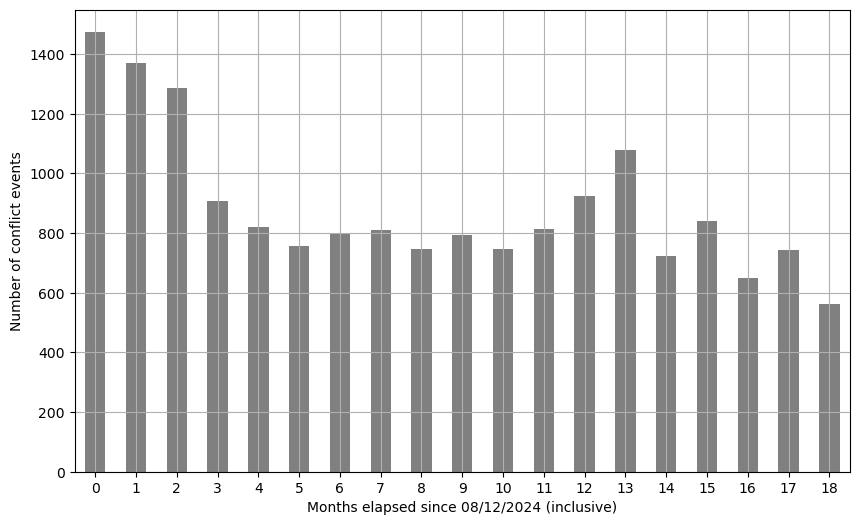

In [5]:
plot_bar = (
    dataset
    .groupby('interval')['event_type']
    .size()
    .plot.bar(
        rot=0, 
        figsize=(10,6), 
        xlabel='Months elapsed since 08/12/2024 (inclusive)', 
        ylabel='Number of conflict events', 
        color='#808080', 
        grid=True))

Part 2: Looking at Geography and Actors for Transfer of Territory

In [62]:
dataset_territorial_transfer = (
    dataset[['sub_event_type', 'interval', 'date', 'actor1', 'actor2']]
    .query("sub_event_type == 'Non-violent transfer of territory'")
)

In [ ]:
plot_stacked = (
    dataset
    .groupby('interval', 'event_type')['event_type']
    .size()
    # .pipe(lambda s: s / s.groupby(level=0).transform('sum'))
    .plot.bar(stacked=True, rot=0, figsize=(10,6), xlabel='interval', ylabel='event_type'))

    - plotly 

In [ ]:
fig = px.bar(
    dataset,
    x="interval",
    y="event",
    pattern_shape_sequence=[".", "x", "+"])
    
fig.show()

In [ ]:
plot_scatter = (
    dataset
    .groupby('interval', 'event_type')['event_type']
    .size()
    .plot
)

In [ ]:
# df_first_month = df[df['interval'] == 0]
# df_first_month

"use groupby to look at number of events and violent events since regime transfer"

df_count_interval = dataset.groupby('interval')["sub_event_type"].size()

df_count_interval


In [4]:
df_interval_and_events = dataset[['interval','event_type', 'sub_event_type', 'date']]
df_event_count = df_interval_and_events.groupby('interval')['event_type'].size()
type(df_event_count)

pandas.Series

In [86]:
def df_index(dataframe):
    rows = len(dataframe)

    dataframe.index = range(1, rows+1)
    
    return dataframe

In [ ]:
df_interval_boundaries = dataset[['interval', 'start date', 'end date']].drop_duplicates()
df_index(df_interval_boundaries)

In [9]:
df_events = pd.merge(df_event_count, df_interval_boundaries, on='interval')
df_events = df_events.rename(columns = {'event_type':'event count', 'start date': "interval start", 'end date': 'interval end'})
df_events.to_csv(dir_processed/'events_summary.csv', index=False)
df_events

,interval,event count,interval start,interval end
0,0,1475,2024-12-08,2025-01-07
1,1,1370,2025-01-08,2025-02-07
2,2,1285,2025-02-08,2025-03-10
3,3,909,2025-03-11,2025-04-10
4,4,820,2025-04-11,2025-05-11
5,5,758,2025-05-12,2025-06-11
6,6,798,2025-06-12,2025-07-12
7,7,809,2025-07-13,2025-08-12
8,8,746,2025-08-13,2025-09-12
9,9,795,2025-09-13,2025-10-13


In [ ]:
df_events_sub_cat = (
    dataset
    .group_by('interval', 'event_type', 'sub_event_type')
)
)

In [ ]:
"function doesn't work"

df_events_test = (
    dataset
    .groupby('interval', 'event_type'),
    .agg('size'),
    .reset_index()
    )

SyntaxError: invalid syntax (3827163459.py, line 4)

In [ ]:
df_count_event_type = dataset.groupby("sub_event_type").size()
df_count_event_type

In [ ]:
# event_type = dataset.groupby("event_type").count()
# event_type
# event_type = dataset.groupby("event_type").size()
# event_type
event_type.reset_index(name = 'count')

In [ ]:
# event_types = dataset.groupby(['event_type', 'sub_event_type']).size() 
event_types.reset_index(name = 'count')
event_types

In [ ]:
index = [range(1,len(event_by_interval)+1)]

In [ ]:
"group interval, then event_type"

event_by_interval = pd.DataFrame(dataset.groupby(["interval", "event_type"])['event_type'].size())
event_by_interval

event_by_interval = event_by_interval.rename(columns={'interval':'interval', 'event_type':'count'})
event_by_interval = event_by_interval.rename(columns={'event_type':'event'})
event_by_interval.to_csv(dir_processed/'event_by_interval.csv', index=True)
event_by_interval.reindex(index) "doesn't reindex"
event_by_interval

In [ ]:
df_event_by_interval = pd.DataFrame([event_by_interval], columns=['interval', 'event', 'count'])
df_event_by_interval

In [ ]:
event_by_interval = (
    dataset
    .query()
    .pipe()
    .groupby()
    .apply()
)

In [ ]:
"create a bar plot of the 'event_type' column, x = interval"

plot_events_per_interval = dataset.plot.bar(x = "interval", y = 'event_type')